# Let's implement the Tuthill CPG in SNS-Toolbox


In [2]:
from sns_toolbox.neurons import SpikingNeuron, NonSpikingNeuron
from sns_toolbox.networks import Network
from sns_toolbox.connections import SpikingSynapse, NonSpikingSynapse
from sns_toolbox.renderer import render

In [3]:
# Organism-specific parameters
v_rest = -60.0 # mV
v_thresh = -40.0 # mV
e_gaba = -55.0 # mV
e_glut = -71.0 # mV
e_achl = 0.0 # mV
tau = 10.0 # ms
tau_achl = 2.0 # ms
tau_gaba = 15.0 # ms
scale_ach = 10.0
scale_gaba = 10.0

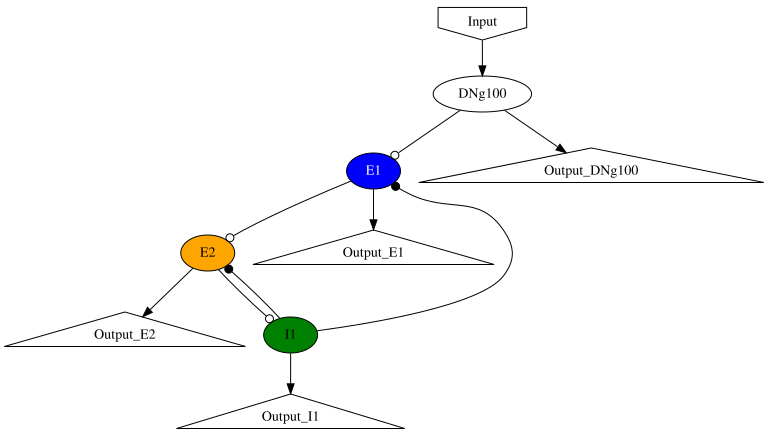

In [4]:
# Network initialization
net_cpg = Network()

# Neuron params
nrn_base = SpikingNeuron(resting_potential=v_rest, membrane_capacitance=tau, threshold_initial_value=v_thresh)

net_cpg.add_neuron(nrn_base, name='DNg100')
net_cpg.add_neuron(nrn_base, name='E1', color='blue')
net_cpg.add_neuron(nrn_base, name='E2', color='orange')
net_cpg.add_neuron(nrn_base, name='I1', color='green')

# Synaptic Connectivity
        # DN E1 E2 I1 (presynaptic)
weights = [[0, 0, 0, 0], # DN (postsynaptic)
           [187, 0, 19, -531], # E1 (postsynaptic)
           [0, 539, 0, -172], # E2 (postsynaptic)
           [0, 17, 71, 0]  # I1 (postsynaptic)
]
max_w = 539

net_cpg.add_connection(SpikingSynapse(max_conductance=100000, conductance_increment=scale_ach*weights[1][0]/max_w, reversal_potential=e_achl, time_constant=tau_achl), 'DNg100', 'E1')
net_cpg.add_connection(SpikingSynapse(max_conductance=100000, conductance_increment=scale_ach*weights[2][1]/max_w, reversal_potential=e_achl, time_constant=tau_achl), 'E1', 'E2')
net_cpg.add_connection(SpikingSynapse(max_conductance=100000, conductance_increment=scale_ach*weights[3][2]/max_w, reversal_potential=e_achl, time_constant=tau_achl), 'E2', 'I1')
net_cpg.add_connection(SpikingSynapse(max_conductance=100000, conductance_increment=-scale_gaba*weights[1][3]/max_w, reversal_potential=e_gaba, time_constant=tau_gaba), 'I1', 'E1')
net_cpg.add_connection(SpikingSynapse(max_conductance=100000, conductance_increment=-scale_gaba*weights[2][3]/max_w, reversal_potential=e_gaba, time_constant=tau_gaba), 'I1', 'E2')

net_cpg.add_input('DNg100', name='Input')
net_cpg.add_output('DNg100', name='Output_DNg100', spiking=True)
net_cpg.add_output('E1', name='Output_E1', spiking=True)
net_cpg.add_output('E2', name='Output_E2', spiking=True)
net_cpg.add_output('I1', name='Output_I1', spiking=True)

render(net_cpg, view=True, save=False)


In [5]:
import numpy as np
dt = 0.1 # ms
t_sim = 1000 # ms
t = np.arange(0, t_sim, dt)

model = net_cpg.compile(dt=dt)

inputs = np.zeros([len(t), 1])
inputs[1000:-1000] = 100.0

outputs = np.zeros((len(t), 4))

for i in range(len(t)):
    outputs[i, :] = model(inputs[i, :])

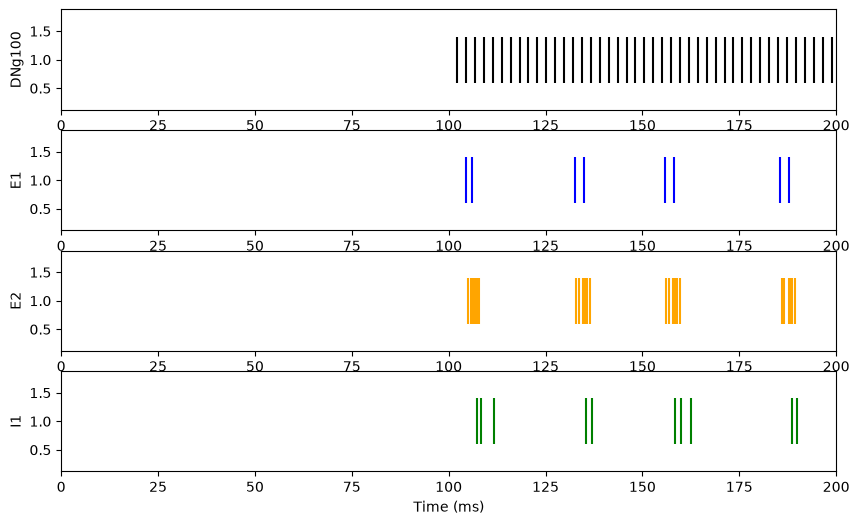

In [6]:
import matplotlib.pyplot as plt
from sns_toolbox.plot_utilities import spike_raster_plot
t_max = 200
data = outputs.transpose()
plt.figure(figsize=(10, 6))
plt.subplot(4, 1, 1)
spike_raster_plot(t, data[:][0], colors=['black'])
plt.ylabel('DNg100')
plt.xlim(0,t_max)
plt.subplot(4, 1, 2)
spike_raster_plot(t, data[:][1], colors=['blue'])
plt.ylabel('E1')
plt.xlim(0,t_max)
plt.subplot(4, 1, 3)
spike_raster_plot(t, data[:][2], colors=['orange'])
plt.ylabel('E2')
plt.xlim(0,t_max)
plt.subplot(4, 1, 4)
spike_raster_plot(t, data[:][3], colors=['green'])
plt.ylabel('I1')
plt.xlabel('Time (ms)')
plt.xlim(0,t_max)

plt.show()

# Non-Spiking Abstraction

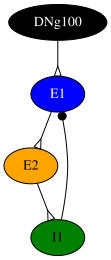

In [7]:
R = 1
E_gaba = -0.5
E_glut = -0.5
E_ach = 3

tau_ach = 2.0
tau_gaba = 150.0

k_ach = 1.0
k_ach_strong = 2.9
k_gaba = 0.01

net = Network()
nrn_ach = NonSpikingNeuron(resting_potential=0.0, membrane_capacitance=tau_ach)
net.add_neuron(nrn_ach, name='DNg100', color='black')
net.add_neuron(nrn_ach, name='E1', color='blue')
net.add_neuron(nrn_ach, name='E2', color='orange')

nrn_gaba = NonSpikingNeuron(resting_potential=0.0, membrane_capacitance=tau_gaba)
net.add_neuron(nrn_gaba, name='I1', color='green')

g_ach = (k_ach*R)/(E_ach - k_ach*R)
syn_ach = NonSpikingSynapse(max_conductance=g_ach, reversal_potential=E_ach, e_lo=0.0, e_hi=1.0)
net.add_connection(syn_ach, 'DNg100', 'E1')

g_ach_strong = (k_ach_strong*R)/(E_ach - k_ach_strong*R)
syn_ach_strong = NonSpikingSynapse(max_conductance=g_ach_strong, reversal_potential=E_ach, e_lo=0.0, e_hi=1.0)

net.add_connection(syn_ach_strong, 'E1', 'E2')

net.add_connection(syn_ach, 'E2', 'I1')

g_gaba = 1/k_gaba - 1
syn_gaba = NonSpikingSynapse(max_conductance=g_gaba, reversal_potential=E_gaba, e_lo=0.0, e_hi=1.0)
net.add_connection(syn_gaba, 'I1', 'E1')
# net.add_connection(syn_gaba, 'I1', 'E2')

render(net, view=True, save=False)

In [8]:
net.add_input('DNg100', name='Input')
net.add_output('DNg100', name='Output_DNg100', spiking=False)
net.add_output('E1', name='Output_E1', spiking=False)
net.add_output('E2', name='Output_E2', spiking=False)
net.add_output('I1', name='Output_I1', spiking=False)

In [9]:
dt = 0.1 # ms
t_sim = 1000 # ms
t = np.arange(0, t_sim, dt)

model = net.compile(dt=dt)

inputs = np.zeros([len(t), 1])
inputs[1000:-1000] = 100.0

outputs = np.zeros((len(t), 4))

for i in range(len(t)):
    outputs[i, :] = model(inputs[i, :])

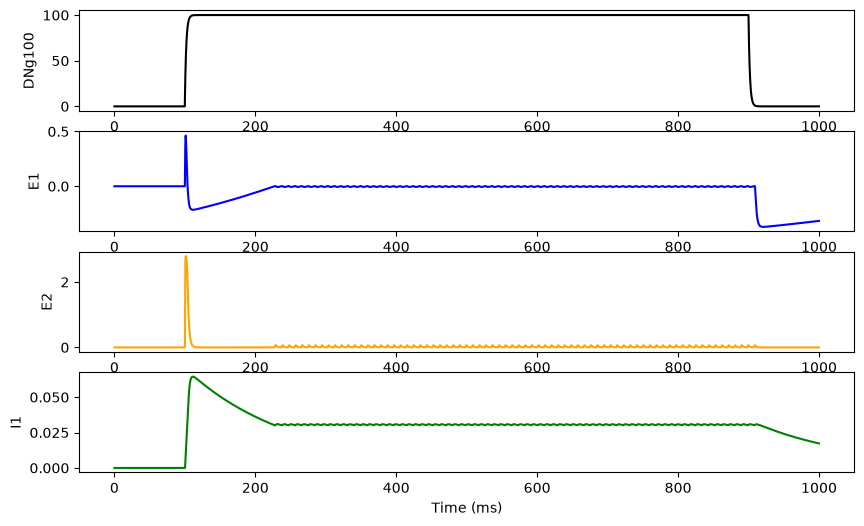

In [10]:
data = outputs.transpose()
plt.figure(figsize=(10, 6))
plt.subplot(4, 1, 1)
plt.plot(t, data[0,:], color='black')
plt.ylabel('DNg100')
plt.subplot(4, 1, 2)
plt.plot(t, data[1,:], color='blue')
plt.ylabel('E1')
plt.subplot(4, 1, 3)
plt.plot(t, data[2,:], color='orange')
plt.ylabel('E2')
plt.subplot(4, 1, 4)
plt.plot(t, data[3,:], color='green')
plt.ylabel('I1')
plt.xlabel('Time (ms)')

plt.show()

In [ ]:
def neuron_update(state, alpha_ach, alpha_gaba, in_ach, in_gaba, dt, tau_mem, tau_ach, tau_gaba):
    alpha_gaba_next = alpha_gaba + dt/tau_gaba*(-alpha_gaba + in_gaba)
    alpha_ach_next = alpha_ach + dt/tau_ach*(-alpha_ach + in_ach)
    state_next = state + dt/tau_mem*(-(1+alpha_gaba)*state + alpha_ach)
    out = np.clip(state_next, 0, 1)
    return out, state_next, alpha_ach_next, alpha_gaba_next
